# M2 — Breaking the model, and checking the harness

Two jobs. Get FGSM, PGD and a patch attack running against the M1 baseline — and then
**verify the attack harness itself** using Athalye's diagnostics, because an attack
that is quietly broken produces exactly the same output as a robust model.

### The two threat models are not comparable

$$S_{\ell_\infty} = \{\delta : \lVert\delta\rVert_\infty \le \varepsilon\}
\qquad
S_{\mathrm{patch}} = \{\delta : \operatorname{supp}(\delta) \subseteq P\}$$

The first bounds *magnitude* everywhere; the second bounds *support*, and inside the
patch the perturbation is **unbounded** — RSA evaluates at $\varepsilon = 255/255$.
Never compare a number from one against a number from the other without saying so.

In [1]:
# Make the `fyp` package importable whether you run this from notebooks/ or code/.
import sys, pathlib
_root = pathlib.Path.cwd()
for _ in range(3):
    if (_root / "fyp" / "__init__.py").exists():
        break
    _root = _root.parent
sys.path.insert(0, str(_root))

import torch
from fyp import config, data, models, hooks, metrics, attacks, diagnostics

config.seed_everything()
device = config.get_device()
print(config.describe())

ds, wnids, class_indices = data.build_dataset()
clf, info = models.load_model(class_indices=class_indices)
loader = data.make_loader(data.eval_subset(ds))
x, y = next(iter(loader))
x, y = x.to(device), y.to(device)
print(f"batch: {tuple(x.shape)}, pixel range [{x.min():.3f}, {x.max():.3f}]")

model        : deit_small_patch16_224
scale        : full  (imagenet100, 512 eval images, batch 32, 100 attack steps)
device       : cuda
data root    : code\data
results root : code\results
gpu          : NVIDIA GeForce RTX 4050 Laptop GPU (5.3 GB free / 6.4 GB)
note         : Matches RSA's evaluation protocol. Needs the ImageNet-100 subset on disk.


batch: (32, 3, 224, 224), pixel range [0.000, 1.000]


## Step 1 — FGSM and PGD

`attacks.fgsm` is one signed gradient step. `attacks.pgd` iterates and projects back
into the ball, keeping the best result per image across restarts.

Both take a model that eats `[0,1]` images, so the perturbation budget is in natural
pixel space.

In [2]:
EPS = 8/255

clean_ok = attacks.accuracy(clf, x, y)
x_fgsm = attacks.fgsm(clf, x, y, eps=EPS)
x_pgd  = attacks.pgd(clf, x, y, eps=EPS, steps=20, restarts=2)

for name, adv in [("FGSM", x_fgsm), ("PGD-20 x2", x_pgd)]:
    r = attacks.report(clean_ok, attacks.accuracy(clf, adv, y))
    print(f"{name:12s} clean {r['clean_acc']:5.1f}%   robust {r['robust_acc']:5.1f}%   ASR {r['asr']:5.1f}%")

FGSM         clean  96.9%   robust  71.9%   ASR  25.8%
PGD-20 x2    clean  96.9%   robust   0.0%   ASR 100.0%


## Step 2 — Athalye's warning signs

**Run these on every model you ever evaluate, including your own.** They are the
cheapest possible insurance against reporting a broken attack as robustness, and they
belong in the methodology chapter.

On an *undefended* model all of them should pass. If they do not, the harness is
wrong, and now is when you want to find that out.

| # | Sign that something is wrong |
|---|---|
| 1 | One-step beats iterative — PGD is stuck |
| 2 | Black-box beats white-box — extra knowledge is not being used |
| 3 | Unbounded attack fails to reach 100% — the optimiser is broken, not the model robust |
| 4 | Random search beats gradient descent — you are following a bad gradient |
| 5 | Raising the budget does not raise success — success should be monotone |

The checks live in `fyp.diagnostics` rather than in this notebook, because Gate A
re-runs them against RSA. They accumulate per-example correctness across batches, so
the sample size is set by how many batches are passed in and not by GPU memory. Sign 2
needs a surrogate model to transfer from and stays deferred until there is a defense.

> **The output of the next cell was cleared on 8 September 2026.**
> The committed run predated the 29 August fixes to how the warning signs are
> scored, and two of its numbers were superseded rather than merely re-rounded:
> random-search error was **7.42%**, now **1.95%**, and the budget ladder read
> **13.28 / 0.39 / 0 / 0 / 0**, now **16.41 / 0 / 0 / 0 / 0**.
>
> `results/m2_attacks.json` carries the corrected run and is the ground truth for
> every number in this notebook. Re-run the cell to repopulate it.


In [ ]:
from itertools import islice

# A seeded draw at the size measured, not the front of the 512-image loader above:
# `eval_subset` sorts its indices, so a prefix is the lowest order statistics of the
# sample and lands in a prefix of the class directories. Six PGD runs per batch:
# eps=1.0 plus the sweep.
N_SIGN_IMAGES = config.SCALE.n_mechanism_images
n_batches = -(-N_SIGN_IMAGES // config.SCALE.batch_size)
sign_loader = data.make_loader(data.eval_subset(ds, N_SIGN_IMAGES))

signs = diagnostics.warning_signs(clf, islice(sign_loader, n_batches), eps=EPS)
print()
diagnostics.print_report(signs)

## Step 3 — The patch threat model

Now the attack that matters. `attacks.patch_pgd` follows RSA's PatchPGD: 10 steps,
step size 0.25, and **unbounded contents inside the patch**.

The location grid is RSA's, verified against all five of their reported counts:
121 locations for 10/20 px, 100 for 30/40 px, 81 for 50 px, stride 20.

> **The mismatch to remember.** RSA's adversarial *training* samples **one uniformly
> random location per image**, while evaluation searches this entire grid for the
> worst one. Train on random, get attacked at the argmax — that gap is what
> attention-guided patch selection exists to close, and it is the most likely thing to
> silently cap Part B.

In [4]:
SIZE = 32
locs = attacks.patch_locations(SIZE)
print(f"{SIZE}px patch -> {len(locs)} evaluation locations (stride 20)")
print("RSA counts: 10px->121  20px->121  30px->100  40px->100  50px->81")
print("ours      :", "  ".join(f"{s}px->{len(attacks.patch_locations(s))}" for s in (10,20,30,40,50)))

STEPS = 20   # keep this the SAME as the sweep below, or the comparison is meaningless
x_patch = attacks.patch_pgd(clf, x, y, top=96, left=96, size=SIZE, steps=STEPS)
r = attacks.report(clean_ok, attacks.accuracy(clf, x_patch, y))
print()
print(f"single fixed location: robust {r['robust_acc']:.1f}%   ASR {r['asr']:.1f}%")

32px patch -> 100 evaluation locations (stride 20)
RSA counts: 10px->121  20px->121  30px->100  40px->100  50px->81
ours      : 10px->121  20px->121  30px->100  40px->100  50px->81



single fixed location: robust 43.8%   ASR 54.8%


### Worst-case over locations

An image counts as robust only if it survives the attack at **every** location. This
is the honest number, and it is where the cost lives:

$$\text{cost} \;\propto\; N_{\mathrm{images}} \times N_{\mathrm{locations}} \times N_{\mathrm{steps}} \times N_{\mathrm{restarts}}$$

which is why the evaluation set is 512 images and not 50,000. Compute being
unconstrained does not make the *attack budget* unconstrained.

In [5]:
# Subsample the grid; the full sweep is n_locations x steps forward passes.
sub_locs = locs[::12]
print(f"attacking {len(sub_locs)} of {len(locs)} locations (raise this for real numbers)")

x_worst, where = attacks.worst_location_attack(clf, x, y, size=SIZE, locations=sub_locs, steps=STEPS)
r = attacks.report(clean_ok, attacks.accuracy(clf, x_worst, y))
print(f"worst-location: robust {r['robust_acc']:.1f}%   ASR {r['asr']:.1f}%")
print("chosen locations:", where[:6], "...")

attacking 9 of 100 locations (raise this for real numbers)


worst-location: robust 12.5%   ASR 87.1%
chosen locations: [(120, 0), (80, 160), (80, 160), (0, 0), (80, 160), (160, 80)] ...


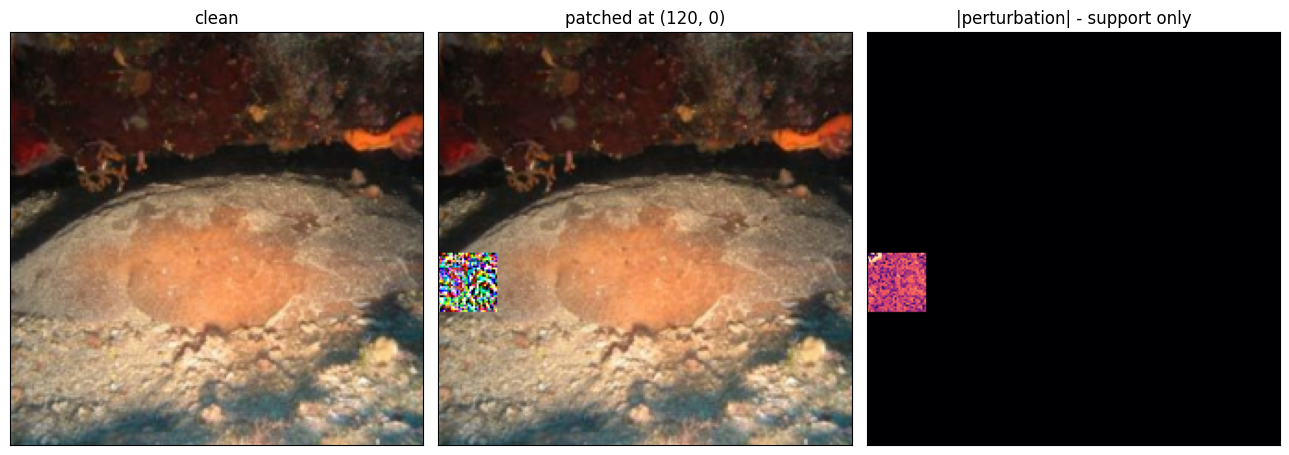

perturbed pixels: 2.04% of the image (a 32px patch is 2.04%)


In [6]:
import matplotlib.pyplot as plt

i = 0
fig, ax = plt.subplots(1, 3, figsize=(13, 4.5))
pert = (x_worst - x)[i].cpu()
ax[0].imshow(x[i].cpu().permute(1,2,0)); ax[0].set_title("clean")
ax[1].imshow(x_worst[i].cpu().permute(1,2,0)); ax[1].set_title(f"patched at {where[i]}")
ax[2].imshow(pert.abs().amax(0), cmap="magma"); ax[2].set_title("|perturbation| - support only")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

frac = (pert.abs().amax(0) > 0).float().mean().item()
print(f"perturbed pixels: {100*frac:.2f}% of the image (a {SIZE}px patch is {100*SIZE**2/224**2:.2f}%)")

## Recap

You now have: FGSM, PGD, a patch attack, worst-case-over-locations, and a harness that
passes Athalye's diagnostics on an undefended model.

**What is still missing before any of this is a result:** the attacks here are simple
PGD. RSA evaluates with **PatchAutoPGD** — AutoPGD(DLR), 100 steps, adaptive step
size — which is meaningfully stronger. Matching it is part of Gate A.

**Next:** `M3_instrumentation.ipynb` — the three measurements that decide research
questions before any expensive code gets written.

## Record the run

Writes attack strengths and Athalye's five warning signs to `results/m2_attacks.json`.


In [7]:
# --- run record (fyp.results) ---
from fyp import results

def _rep(adv):
    r = attacks.report(clean_ok, attacks.accuracy(clf, adv, y))
    return {k: round(float(v), 2) for k, v in r.items()}

results.save("m2_attacks", {
    "eps": EPS,
    "attacks": {
        "fgsm": _rep(x_fgsm),
        "pgd20_x2": _rep(x_pgd),
        f"patch_pgd_{SIZE}px_fixed_loc": _rep(x_patch),
        f"patch_pgd_{SIZE}px_worst_of_{len(sub_locs)}_locs": _rep(x_worst),
    },
    "athalye_warning_signs": signs,
    "location_grid": {
        f"{s}px": len(attacks.patch_locations(s)) for s in (10, 20, 30, 40, 50)
    },
    "location_grid_rsa_reference": {"10px": 121, "20px": 121, "30px": 100, "40px": 100, "50px": 81},
    "patch_sweep_note": (
        f"worst-location used {len(sub_locs)} of {len(locs)} grid positions and "
        f"{STEPS}-step patch-PGD; RSA uses the full grid with 100-step PatchAutoPGD"
    ),
}, n_eval_images=int(x.shape[0]), attack_steps=STEPS)


wrote code\results\m2_attacks.json  [RESULT]


WindowsPath('code/results/m2_attacks.json')